In [1]:
# --- Colab Setup (skip automatically if running locally) ----------------------
import sys, os

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    # transformers provides HuggingFace PatchTST (fully multivariate)
    subprocess.run(['pip', 'install', 'transformers', '-q'], check=True)

    REPO_URL = 'https://github.com/WoodyChang21/ECE1508_GenAI.git'
    # Clone if missing, otherwise pull the latest Model branch
    if not os.path.exists('/content/ECE1508_GenAI'):
        subprocess.run(
            ['git', 'clone', '--branch', 'Model', REPO_URL, '/content/ECE1508_GenAI'],
            check=True,
        )
    else:
        subprocess.run(
            ['git', '-C', '/content/ECE1508_GenAI', 'fetch', 'origin', 'Model'],
            check=True,
        )
        subprocess.run(
            ['git', '-C', '/content/ECE1508_GenAI', 'reset', '--hard', 'origin/Model'],
            check=True,
        )
    os.chdir('/content/ECE1508_GenAI/notebooks')

    # Verify cloned splits — no manual upload (avoids Colab widget freeze)
    os.makedirs('/content/ECE1508_GenAI/data/predictions', exist_ok=True)
    missing = [
        f for f in ['train.parquet', 'val.parquet', 'test.parquet']
        if not os.path.exists(f'/content/ECE1508_GenAI/data/splits/{f}')
    ]
    if missing:
        raise FileNotFoundError(
            'Missing data splits after clone: ' + ', '.join(missing)
            + '. Ensure the Model branch includes data/splits/*.parquet.'
        )
    print('Data splits found from clone — no upload needed.')

    import torch
    if torch.cuda.is_available():
        print(f'\nGPU: {torch.cuda.get_device_name(0)}')
    else:
        print('\nNo GPU detected. Go to Runtime -> Change runtime type -> T4 GPU.')

print('Setup complete.')


Data splits found from clone — no upload needed.

GPU: NVIDIA A100-SXM4-80GB
Setup complete.


In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import PatchTSTConfig, PatchTSTForPrediction
from scipy.stats import t as student_t
import matplotlib.pyplot as plt

from scripts.models.data_loader import HIST_EXOG_COLS
from scripts.models.metrics import compute_all

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

TARGET_COL = 'return_1h'
ALL_COLS   = [TARGET_COL] + HIST_EXOG_COLS   # 21 columns; return_1h is channel 0
CANDIDATES = [24, 60, 120, 240]
plt.rcParams['figure.figsize'] = (14, 4)

Device: cuda


In [3]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def patch_params(input_size: int):
    patch_len = max(4, min(16, input_size // 4))
    stride    = max(2, patch_len // 2)
    return patch_len, stride


class ZScoreScaler:
    """Fit on training data, transform any split with the same statistics."""
    def fit(self, data: np.ndarray):
        self.mean_ = data.mean(axis=0)
        self.std_  = data.std(axis=0) + 1e-8
        return self

    def transform(self, data: np.ndarray) -> np.ndarray:
        return (data - self.mean_) / self.std_

    def inverse_col0(self, z: np.ndarray) -> np.ndarray:
        """De-normalise the target channel (index 0) back to original scale."""
        return z * self.std_[0] + self.mean_[0]


class WindowDataset(Dataset):
    """
    Produces (past_values, future_values) pairs for PatchTST training.
    past_values  : (context_length, 21)  — all channels, lookback window
    future_values: (1, 21)               — all channels at t+1 (channel 0 is the
                                            training target; the rest ride along
                                            as context only — see train_model)
    """
    def __init__(self, data: np.ndarray, context_length: int):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.ctx  = context_length

    def __len__(self):
        return len(self.data) - self.ctx

    def __getitem__(self, i):
        return {
            'past_values':   self.data[i : i + self.ctx],
            'future_values': self.data[i + self.ctx : i + self.ctx + 1],
        }


def build_model(input_size: int) -> PatchTSTForPrediction:
    patch_len, stride = patch_params(input_size)
    config = PatchTSTConfig(
        num_input_channels=len(ALL_COLS),   # 21: return_1h + 20 features
        context_length=input_size,
        prediction_length=1,
        patch_length=patch_len,
        stride=stride,
        d_model=128,
        num_attention_heads=8,
        num_hidden_layers=3,
        dropout=0.2,
        head_dropout=0.0,
        channel_attention=True,   # let return_1h actually attend to the other 20
                                  # channels' patch representations. Previously
                                  # False (fully channel-independent): return_1h's
                                  # forecast never used the other channels at all,
                                  # despite this setup nominally being "multivariate".
        loss='nll',                       # distributional output, for parity with DeepAR's DistributionLoss
        distribution_output='student_t',  # same distribution family DeepAR uses
    )
    return PatchTSTForPrediction(config)


def _distribution_params(model: PatchTSTForPrediction, past_values: torch.Tensor):
    """
    Bypass model.head.forward()'s final tuple-transpose step, which assumes
    prediction_length > 1 and raises IndexError with a distribution head at
    prediction_length=1 (confirmed: crashes inside PatchTSTPredictionHead.forward
    during both training and inference, in this transformers version).

    Instead, call the encoder and the head's pooling + parameter-projection
    sub-steps directly — same trained weights, just stopping one line before
    the broken reshape.

    Returns (df, loc, scale, win_loc, win_scale), each shape (batch, num_channels).
    (df, loc, scale) are the LEARNED distribution parameters, in the model's own
    per-window-normalised space. win_loc/win_scale are PatchTST's own internal
    per-window instance-normalization stats (RevIN-style, NOT learned — just that
    window's own mean/std), needed to de-normalise (df, loc, scale) back to the
    (globally-normalised) input scale.

    channel_attention only changes internal encoder computation (an extra
    cross-channel attention sublayer per layer); it does not change
    last_hidden_state's shape, so this bypass needs no changes when it's toggled.
    """
    base_out = model.model(past_values=past_values)             # encoder only, no head
    pooled   = base_out.last_hidden_state.mean(dim=2)            # mean-pool across patches: (bs, channels, d_model)
    pooled   = model.head.dropout(model.head.flatten(pooled))
    df, loc, scale = model.head.projection(pooled)               # ParameterProjection -> (bs, channels) each

    win_loc   = base_out.loc[:, 0, :]     # (bs, channels)
    win_scale = base_out.scale[:, 0, :]
    return df, loc, scale, win_loc, win_scale


def train_model(
    model: PatchTSTForPrediction,
    data: np.ndarray,
    context_length: int,
    max_steps: int,
    batch_size: int = 64,
) -> PatchTSTForPrediction:
    dataset = WindowDataset(data, context_length)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-4)
    model.to(DEVICE).train()
    step = 0
    while step < max_steps:
        for batch in loader:
            pv = batch['past_values'].to(DEVICE)
            fv = batch['future_values'].to(DEVICE)[:, 0, :]   # (bs, 21) — squeeze prediction_length=1 axis

            df, loc, scale, win_loc, win_scale = _distribution_params(model, pv)

            # Loss restricted to channel 0 (return_1h) only, matching DeepAR — which
            # is inherently univariate and only ever optimizes its single target.
            # Previously this loss was averaged equally across all 21 channels,
            # diagnosed as the cause of a strong lag-echo behavior: with shared
            # weights across channels and an equal-weighted loss, the model
            # converged on a persistence-like strategy that suits the 20 other
            # (genuinely autocorrelated) channels, and return_1h inherited that
            # strategy despite it being a poor fit for its own near-zero
            # autocorrelation (measured lag-1 corr ~0.01). The model still sees
            # all 21 channels as context (channel-independent patching/encoding
            # is unaffected) — only the gradient signal is now channel-0-only.
            target0   = fv[:, 0]
            df0, loc0, scale0     = df[:, 0], loc[:, 0], scale[:, 0]
            win_loc0, win_scale0  = win_loc[:, 0], win_scale[:, 0]

            standardized_target = (target0 - win_loc0) / win_scale0
            base_dist = torch.distributions.StudentT(df=df0, loc=loc0, scale=scale0)
            log_prob  = base_dist.log_prob(standardized_target) - torch.log(win_scale0)
            loss = -log_prob.mean()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            step += 1
            if step >= max_steps:
                break
    return model


def predict_distribution(
    model: PatchTSTForPrediction,
    full_data: np.ndarray,
    context_length: int,
    start_idx: int,
    batch_size: int = 512,
):
    """
    Batch walk-forward inference, extracting an ANALYTIC point forecast + intervals
    from the model's learned StudentT(df, loc, scale) for channel 0 (return_1h).

    No Monte Carlo needed: PatchTST is a direct (non-recursive) forecaster, so its
    per-step distribution is exactly known in closed form — unlike DeepAR, whose
    recursive-rollout API forces sampling even though it's redundant at h=1.

    Also returns loc_raw / win_loc / win_scale (channel 0, model-input-normalised
    space) separately from the final de-normalised mean/quantiles, so the "lag"
    diagnostic can tell apart two possible causes:
      - loc_raw correlating with y[t-1]  -> the LEARNED weights produced a
        persistence-like strategy (confirmed as the actual cause — see
        train_model's comment; this instrumentation was how it was diagnosed).
      - win_loc correlating with y[t-1] while loc_raw does not -> the effect
        would be coming from PatchTST's own (non-learned) per-window instance
        normalization instead (ruled out: win_loc barely correlates at all).
    """
    n = len(full_data) - start_idx
    windows = np.stack([
        full_data[i - context_length : i]
        for i in range(start_idx, len(full_data))
    ])  # (n, context_length, 21)

    model.eval()
    means, lo_80, hi_80, lo_90, hi_90 = [], [], [], [], []
    loc_raw_list, win_loc_list, win_scale_list = [], [], []
    with torch.no_grad():
        for i in range(0, n, batch_size):
            x = torch.tensor(windows[i : i + batch_size], dtype=torch.float32).to(DEVICE)

            df, loc, scale, win_loc, win_scale = _distribution_params(model, x)

            # channel 0 = return_1h
            df0, loc0, scale0 = df[:, 0].cpu().numpy(), loc[:, 0].cpu().numpy(), scale[:, 0].cpu().numpy()
            wloc0, wscale0    = win_loc[:, 0].cpu().numpy(), win_scale[:, 0].cpu().numpy()

            # Analytic StudentT mean = loc parameter itself (valid since domain_map enforces df > 2)
            mean_z = loc0 * wscale0 + wloc0
            q = {lvl: student_t.ppf(lvl, df0, loc=loc0, scale=scale0) * wscale0 + wloc0
                 for lvl in [0.05, 0.10, 0.90, 0.95]}

            means.append(mean_z)
            lo_80.append(q[0.10]); hi_80.append(q[0.90])
            lo_90.append(q[0.05]); hi_90.append(q[0.95])
            loc_raw_list.append(loc0); win_loc_list.append(wloc0); win_scale_list.append(wscale0)

    return (np.concatenate(means), np.concatenate(lo_80), np.concatenate(hi_80),
            np.concatenate(lo_90), np.concatenate(hi_90),
            np.concatenate(loc_raw_list), np.concatenate(win_loc_list), np.concatenate(win_scale_list))

In [4]:
# ── Load and normalise data ───────────────────────────────────────────────────
train_raw = pd.read_parquet('../data/splits/train.parquet')
val_raw   = pd.read_parquet('../data/splits/val.parquet')
test_raw  = pd.read_parquet('../data/splits/test.parquet')

for df in [train_raw, val_raw, test_raw]:
    df['is_first_bar'] = df['is_first_bar'].astype(float)

# Feature matrix: shape (n_rows, 21); return_1h is column 0 (the target channel)
train_mat = train_raw[ALL_COLS].values.astype(np.float32)
val_mat   = val_raw[ALL_COLS].values.astype(np.float32)
test_mat  = test_raw[ALL_COLS].values.astype(np.float32)

# Fit scaler on train only — no leakage
scaler     = ZScoreScaler().fit(train_mat)
train_norm = scaler.transform(train_mat)
val_norm   = scaler.transform(val_mat)
test_norm  = scaler.transform(test_mat)

trainval_norm = np.concatenate([train_norm, val_norm], axis=0)
full_norm     = np.concatenate([train_norm, val_norm, test_norm], axis=0)

n_train, n_val, n_test = len(train_norm), len(val_norm), len(test_norm)

print(f'Train: {n_train:,}  Val: {n_val:,}  Test: {n_test:,}')
print(f'Input channels ({len(ALL_COLS)}): {ALL_COLS}')

Train: 21,028  Val: 1,744  Test: 2,469
Input channels (21): ['return_1h', 'open', 'high', 'low', 'close', 'volume', 'return_4h', 'return_24h', 'is_first_bar', 'vol_24h', 'vol_60h', 'volume_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_diff', 'bb_upper', 'bb_lower', 'bb_width', 'vix_log', 'vix_change_1h']


In [5]:
# ── Lookback tuning — val MAE per candidate ───────────────────────────────────
# Train on train, walk-forward predict val, pick best input_size.
# max_steps doubled (500->1000 here, 1000->2000 in final training) to test
# whether channel_attention=True's regressed calibration and near-constant
# collapsed predictions are an undertraining artifact: that sublayer roughly
# doubles per-layer attention computation with no corresponding increase in
# training budget in the prior run.
import gc

val_maes = {}

for input_size in reversed(CANDIDATES):
    patch_len, stride = patch_params(input_size)
    model = build_model(input_size)
    model = train_model(model, train_norm, input_size, max_steps=1000)

    z_mean, *_ = predict_distribution(model, trainval_norm, input_size, start_idx=n_train)
    z_true  = val_norm[:, 0]
    val_mae = float(np.mean(np.abs(z_mean - z_true)))

    val_maes[input_size] = val_mae
    print(f'  input_size={input_size:3d}  patch_len={patch_len}  stride={stride}  val MAE={val_mae:.6f}')
    del model   # free GPU memory between candidates
    gc.collect()
    torch.cuda.empty_cache()

best_input_size = min(val_maes, key=val_maes.get)
print(f'\nBest input_size: {best_input_size}  (val MAE={val_maes[best_input_size]:.6f})')

  input_size=240  patch_len=16  stride=8  val MAE=0.538860
  input_size=120  patch_len=16  stride=8  val MAE=0.538877
  input_size= 60  patch_len=15  stride=7  val MAE=0.536928
  input_size= 24  patch_len=6  stride=3  val MAE=0.543702

Best input_size: 60  (val MAE=0.536928)


In [6]:
# ── Final training on train + val ────────────────────────────────────────────
final_model = build_model(best_input_size)
final_model = train_model(final_model, trainval_norm, best_input_size, max_steps=2000)
print(f'Final model trained on {len(trainval_norm):,} rows (train + val), input_size={best_input_size}')

Final model trained on 22,772 rows (train + val), input_size=60


In [7]:
# ── Walk-forward test predictions + metrics ───────────────────────────────────
(y_pred_z, lo_80_z, hi_80_z, lo_90_z, hi_90_z,
 loc_raw, win_loc, win_scale) = predict_distribution(
    final_model, full_norm, best_input_size, start_idx=n_train + n_val
)
z_test_true = test_norm[:, 0]

# De-normalise back to original return_1h scale
y_true = scaler.inverse_col0(z_test_true)
y_pred = scaler.inverse_col0(y_pred_z)
lo_80  = scaler.inverse_col0(lo_80_z)
hi_80  = scaler.inverse_col0(hi_80_z)
lo_90  = scaler.inverse_col0(lo_90_z)
hi_90  = scaler.inverse_col0(hi_90_z)

results = compute_all(y_true, y_pred, lo_80, hi_80, lo_90, hi_90)

print('=== PatchTST Test Results (multivariate — 21 channels, StudentT distribution, analytic intervals) ===')
print(f"  RMSE              : {results['rmse']:.6f}")
print(f"  MAE               : {results['mae']:.6f}")
print(f"  Directional Acc   : {results['dir_acc']:.4f}")
print(f"  Coverage 80%      : {results['coverage_80']:.4f}  (target: 0.80)")
print(f"  Coverage 90%      : {results['coverage_90']:.4f}  (target: 0.90)")
print(f"  Sharpe Ratio      : {results['sharpe']:.4f}")
print(f"  Max Drawdown      : {results['max_drawdown']:.6f}")

# ── Lag diagnostic: is the model's LEARNED loc echoing y[t-1], or is that coming
# from PatchTST's own (non-learned) per-window instance normalization instead? ──
y_lag1_norm = np.roll(z_test_true, 1)
corr_loc_raw  = np.corrcoef(loc_raw[1:], y_lag1_norm[1:])[0, 1]
corr_win_loc  = np.corrcoef(win_loc[1:], y_lag1_norm[1:])[0, 1]
corr_pred     = np.corrcoef(y_pred_z[1:], y_lag1_norm[1:])[0, 1]
print("\n=== Lag diagnostic: correlation with y[t-1] (normalised space) ===")
print(f"  corr(loc_raw,   y[t-1])  : {corr_loc_raw:.4f}   <- learned weights' own signal")
print(f"  corr(win_loc,   y[t-1])  : {corr_win_loc:.4f}   <- non-learned per-window instance norm")
print(f"  corr(final pred, y[t-1]) : {corr_pred:.4f}   <- what actually gets reported/plotted")

=== PatchTST Test Results (multivariate — 21 channels, StudentT distribution, analytic intervals) ===
  RMSE              : 0.004161
  MAE               : 0.002356
  Directional Acc   : 0.4970
  Coverage 80%      : 0.7618  (target: 0.80)
  Coverage 90%      : 0.8615  (target: 0.90)
  Sharpe Ratio      : 0.0031
  Max Drawdown      : -0.221703

=== Lag diagnostic: correlation with y[t-1] (normalised space) ===
  corr(loc_raw,   y[t-1])  : -0.0289   <- learned weights' own signal
  corr(win_loc,   y[t-1])  : 0.1243   <- non-learned per-window instance norm
  corr(final pred, y[t-1]) : 0.1607   <- what actually gets reported/plotted


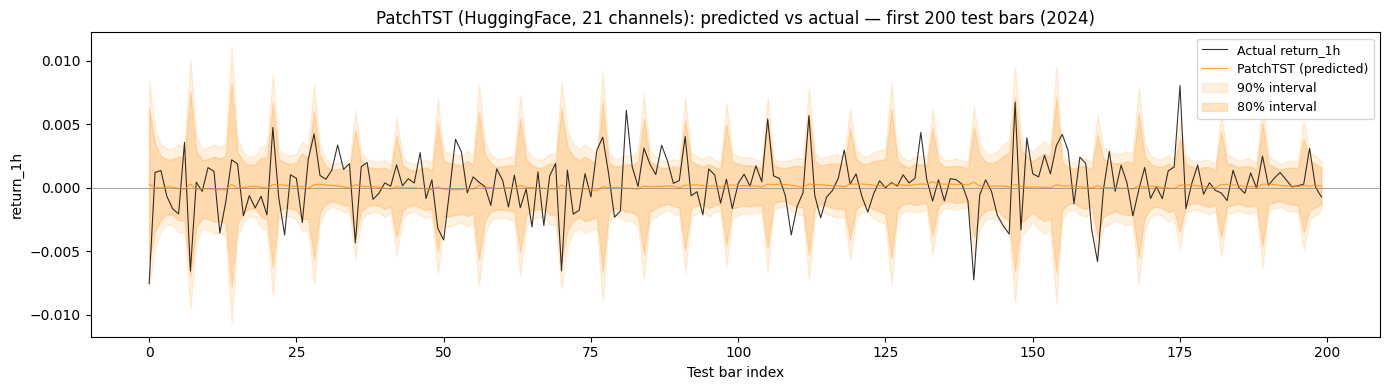

In [8]:
# ── Plot: predicted vs actual, first 200 test bars ────────────────────────────
n = 200
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n), y_true[:n], label='Actual return_1h',      alpha=0.8, linewidth=0.8, color='black')
ax.plot(range(n), y_pred[:n], label='PatchTST (predicted)',  alpha=0.8, linewidth=0.8, color='darkorange')
ax.fill_between(range(n), lo_90[:n], hi_90[:n], alpha=0.12, color='darkorange', label='90% interval')
ax.fill_between(range(n), lo_80[:n], hi_80[:n], alpha=0.22, color='darkorange', label='80% interval')
ax.axhline(0, color='gray', linewidth=0.5)
ax.legend(fontsize=9)
ax.set_title(f'PatchTST (HuggingFace, {len(ALL_COLS)} channels): predicted vs actual — first 200 test bars (2024)')
ax.set_xlabel('Test bar index')
ax.set_ylabel('return_1h')
plt.tight_layout()
plt.show()

In [9]:
# ── Save predictions ──────────────────────────────────────────────────────────
preds_df = pd.DataFrame({
    'ds':        np.arange(n_test),
    'datetime':  test_raw['datetime'].values[:n_test],
    'y':         y_true,
    'pred':      y_pred,
    'lo_80':     lo_80,
    'hi_80':     hi_80,
    'lo_90':     lo_90,
    'hi_90':     hi_90,
    'model':     'PatchTST',
    'loc_raw':   loc_raw,     # learned distribution loc, model-normalised space (lag diagnostic)
    'win_loc':   win_loc,     # per-window instance-norm mean (non-learned, lag diagnostic)
    'win_scale': win_scale,   # per-window instance-norm std (non-learned, lag diagnostic)
})
preds_df.to_parquet('../data/predictions/patchtst_preds.parquet', index=False)
print(f'Saved {len(preds_df):,} rows → data/predictions/patchtst_preds.parquet')
print(preds_df.head(3))

Saved 2,469 rows → data/predictions/patchtst_preds.parquet
   ds            datetime         y      pred     lo_80     hi_80     lo_90  \
0   0 2024-01-02 09:30:00 -0.007552  0.000278 -0.005738  0.006294 -0.007866   
1   1 2024-01-02 10:30:00  0.001208  0.000026 -0.003392  0.003443 -0.004668   
2   2 2024-01-02 11:30:00  0.001366  0.000008 -0.002500  0.002515 -0.003434   

      hi_90     model   loc_raw   win_loc  win_scale  
0  0.008422  PatchTST  0.069546  0.010920   0.627756  
1  0.004720  PatchTST  0.018245 -0.021009   0.674190  
2  0.003449  PatchTST  0.003429 -0.015559   0.675343  
